In [1]:
with open(r"Tiny_Shakespeare.txt", 'r') as f:
    list_of_sentences = f.read().splitlines()

    tiny_shakespeare = []
    for sentence in list_of_sentences:
        l = sentence.lower().split('&')
        # l = ' '.join(l).split('&')
        l = ' '.join(l).split('!')
        l = ' '.join(l).split('$')
        l = ' '.join(l).split(',')
        l = ' '.join(l).split('-')
        l = ' '.join(l).split('3')
        l = ' '.join(l).split(':')
        l = ' '.join(l).split(';')
        l = ' '.join(l).split('?')
        l = ' '.join(l).split("'")
        l = ' '.join(l).split(".")
        l = ' '.join(l).split(" ")
        tiny_shakespeare.extend(l)
        
        
tiny_shakespeare[:10]

['first',
 'citizen',
 '',
 'before',
 'we',
 'proceed',
 'any',
 'further',
 '',
 'hear']

In [2]:
tiny_shakespeare = [word for word in tiny_shakespeare if word != ""]
len(tiny_shakespeare)

208503

In [3]:
chars = sorted(set(''.join(tiny_shakespeare)))
print(chars)

['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [4]:
counts = dict()
for word in tiny_shakespeare:
    new_word = "@" + word + "@" # @ is use for stating and ending character.
    for w1, w2 in zip(new_word, new_word[1:]):
        pair = w1 + w2
        counts[pair] = counts.get(pair, 0) + 1
counts 

{'@f': 8138,
 'fi': 1336,
 'ir': 2781,
 'rs': 2716,
 'st': 7393,
 't@': 22298,
 '@c': 7439,
 'ci': 1057,
 'it': 6340,
 'ti': 3746,
 'iz': 358,
 'ze': 330,
 'en': 9049,
 'n@': 13279,
 '@b': 10866,
 'be': 4680,
 'ef': 903,
 'fo': 3940,
 'or': 9306,
 're': 10309,
 'e@': 38688,
 '@w': 13963,
 'we': 3460,
 '@p': 5927,
 'pr': 2074,
 'ro': 4301,
 'oc': 373,
 'ce': 4034,
 'ee': 4033,
 'ed': 4030,
 'd@': 19882,
 '@a': 18011,
 'an': 12988,
 'ny': 484,
 'y@': 14542,
 'fu': 573,
 'ur': 5418,
 'rt': 2444,
 'th': 26047,
 'he': 19268,
 'er': 12470,
 'r@': 15336,
 '@h': 14214,
 'ea': 6327,
 'ar': 8311,
 '@m': 13001,
 'me': 6739,
 '@s': 16822,
 'sp': 1253,
 'pe': 2475,
 'ak': 1577,
 'k@': 2760,
 'al': 4513,
 'll': 6621,
 'l@': 7415,
 '@y': 6249,
 'yo': 5585,
 'ou': 13078,
 'u@': 4661,
 '@r': 3624,
 'es': 7113,
 'so': 3246,
 'ol': 2150,
 'lv': 175,
 've': 6078,
 'ra': 2847,
 'at': 8547,
 '@t': 29548,
 'to': 6873,
 'o@': 12209,
 '@d': 8043,
 'di': 1996,
 'ie': 2409,
 'ha': 10637,
 'fa': 1656,
 'am': 1998

In [5]:
stoi = dict()
for idx, value in enumerate(chars):
    stoi[value] = idx + 1
stoi['@'] = 0
itos = {i:s for s, i in stoi.items()}

In [6]:
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '@'}

In [7]:
import torch
torch.set_printoptions(sci_mode=False) # fix the values 5.5600e+02 = 556

In [8]:
tensor = torch.ones(27, 27)
tensor

tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1

In [9]:
for i in range(27):
    for j in range(27):
        char1 = itos[i]
        char2 = itos[j]
        pair = char1 + char2
        count = counts.get(pair, 0)
        tensor[i,j] = count
tensor

tensor([[    0., 18011., 10866.,  7439.,  8043.,  3485.,  8138.,  5030., 14214.,
         13879.,   707.,  2418.,  7349., 13001.,  6440.,  9067.,  5927.,   628.,
          3624., 16822., 29548.,  2129.,  1488., 13963.,    22.,  6249.,    16.],
        [ 4132.,     0.,   887.,  1623.,  2305.,    40.,   370.,  1041.,   109.,
          2327.,    57.,  1577.,  4513.,  1998., 12988.,    18.,   908.,     3.,
          8311.,  4427.,  8547.,  1169.,  2475.,   624.,    25.,  2778.,    74.],
        [  131.,  1065.,    62.,     0.,    11.,  4680.,     0.,     0.,    31.,
           546.,    72.,     0.,  1314.,     6.,     2.,  1336.,     0.,     0.,
          1445.,   132.,   100.,  2122.,     0.,     1.,     0.,  1026.,     0.],
        [  109.,  2229.,     0.,   216.,     0.,  4034.,     0.,     0.,  3703.,
          1057.,     0.,  1251.,   873.,     0.,     0.,  3823.,     0.,    20.,
           636.,    10.,   671.,   675.,     0.,     0.,     0.,   136.,     0.],
        [19882.,  1067.,

In [10]:
# Model smoothing
tensor = tensor + 1
tensor

tensor([[    1., 18012., 10867.,  7440.,  8044.,  3486.,  8139.,  5031., 14215.,
         13880.,   708.,  2419.,  7350., 13002.,  6441.,  9068.,  5928.,   629.,
          3625., 16823., 29549.,  2130.,  1489., 13964.,    23.,  6250.,    17.],
        [ 4133.,     1.,   888.,  1624.,  2306.,    41.,   371.,  1042.,   110.,
          2328.,    58.,  1578.,  4514.,  1999., 12989.,    19.,   909.,     4.,
          8312.,  4428.,  8548.,  1170.,  2476.,   625.,    26.,  2779.,    75.],
        [  132.,  1066.,    63.,     1.,    12.,  4681.,     1.,     1.,    32.,
           547.,    73.,     1.,  1315.,     7.,     3.,  1337.,     1.,     1.,
          1446.,   133.,   101.,  2123.,     1.,     2.,     1.,  1027.,     1.],
        [  110.,  2230.,     1.,   217.,     1.,  4035.,     1.,     1.,  3704.,
          1058.,     1.,  1252.,   874.,     1.,     1.,  3824.,     1.,    21.,
           637.,    11.,   672.,   676.,     1.,     1.,     1.,   137.,     1.],
        [19883.,  1068.,

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

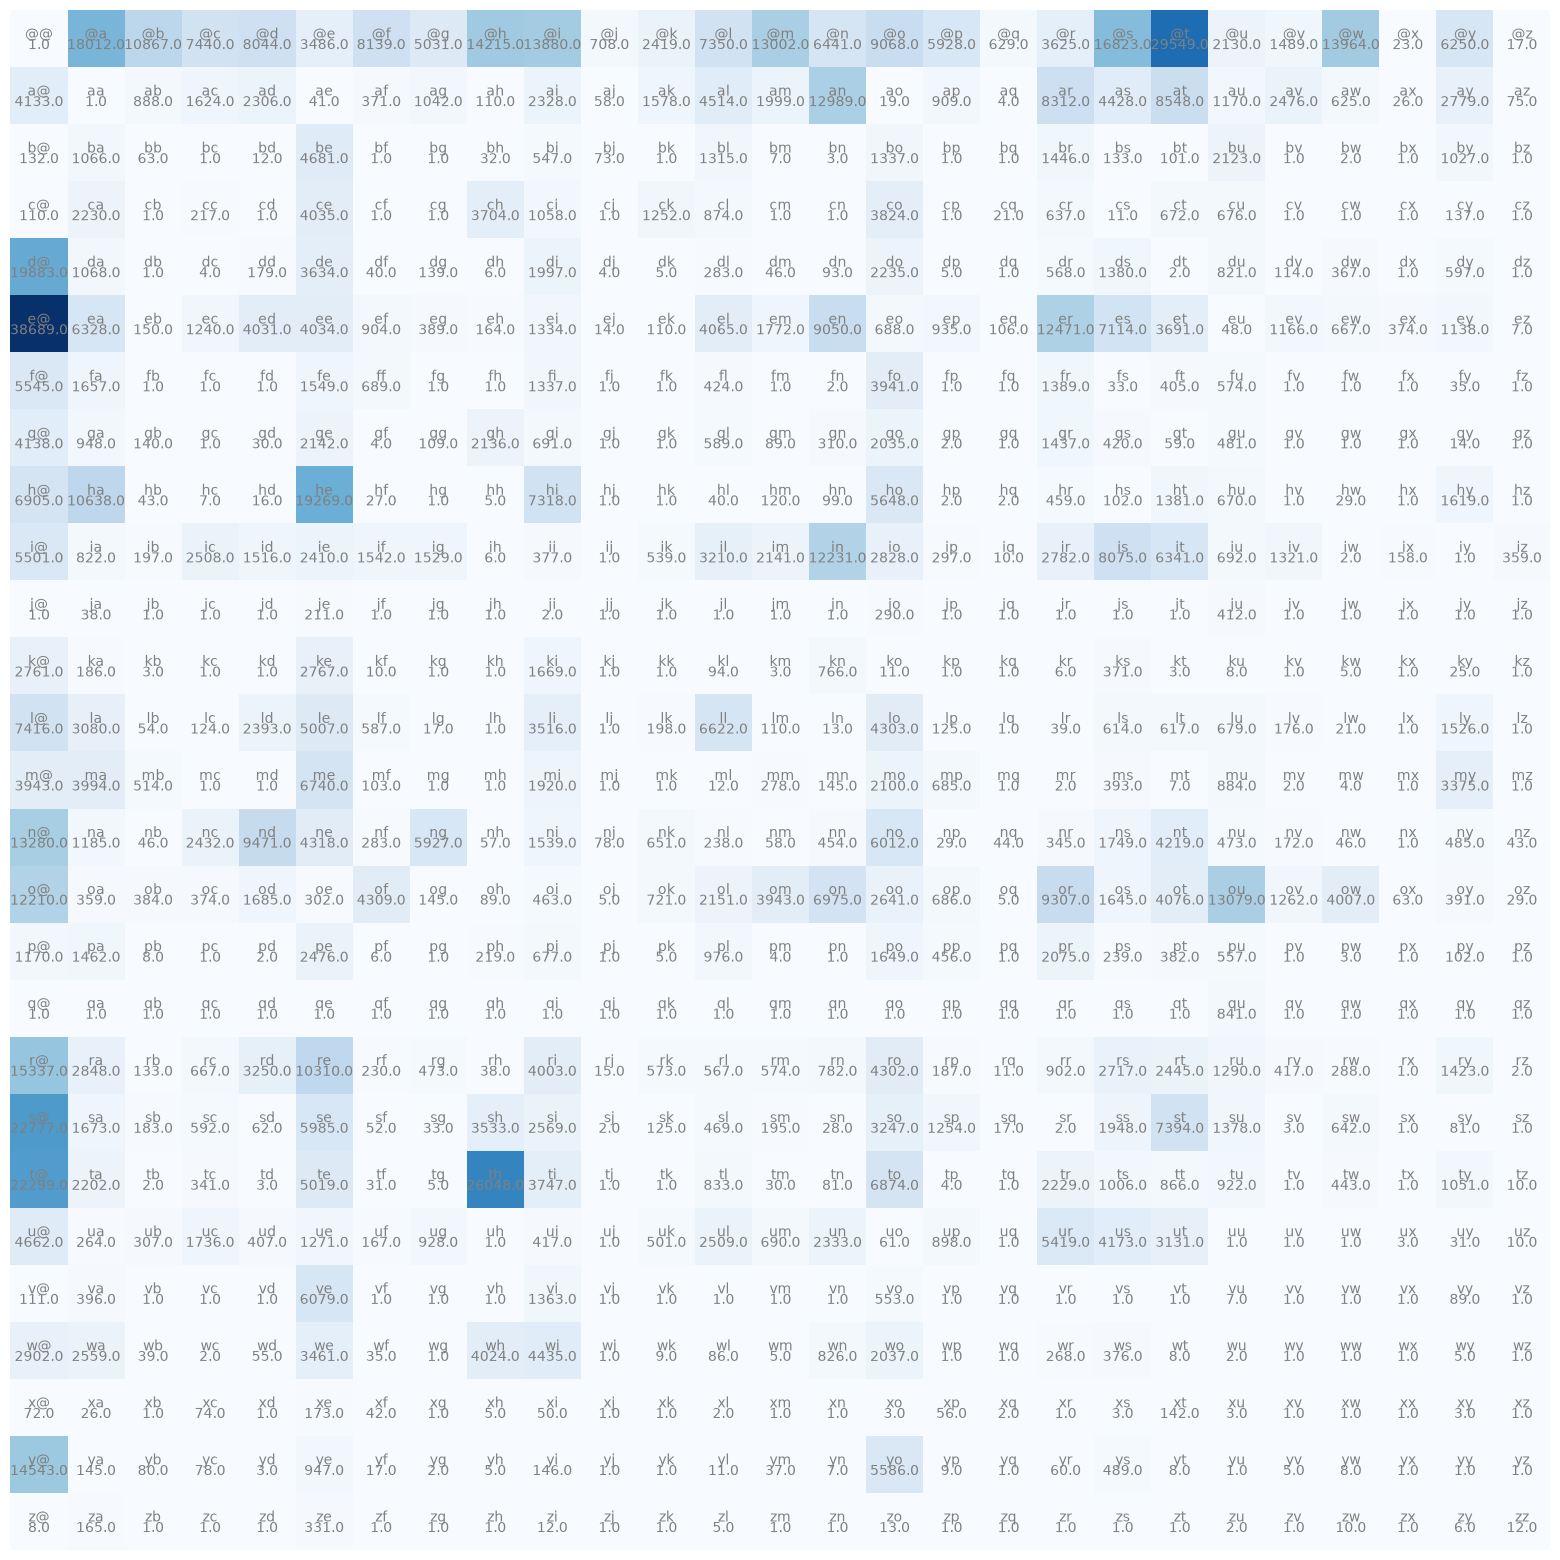

In [12]:
plt.figure(figsize=(20,20))
plt.imshow(tensor, cmap='Blues')
for i in range(27): 
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', color='gray') # put characters
        plt.text(j, i, tensor[i, j].item(), ha='center', va='top', color='gray') # put coutns of characters
plt.axis('off')

In [13]:
# converting counts into proability
P = tensor / tensor.sum(1, keepdim=True)
P[0].sum()

tensor(1.0000)

In [14]:
g = torch.Generator().manual_seed(922112211)
p = torch.randn(3, generator=g).exp()
p = p / p.sum()
p

tensor([0.4557, 0.4773, 0.0670])

In [15]:
char = torch.multinomial(p, num_samples=100, replacement=True, generator=g)
char

tensor([1, 1, 2, 0, 2, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 2, 1, 0, 0, 0, 1, 1, 1, 1,
        0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 2, 0, 1, 1, 0, 1, 0, 1, 1,
        1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 2, 1, 0, 0, 0, 0, 0,
        0, 1, 0, 1, 1, 2, 1, 2, 1, 1, 0, 0, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 0, 1])

In [16]:
for _ in range(5):
    idx = 0
    text = ""
    while True:
        idx = torch.multinomial(P[idx],  num_samples=1, replacement=True, generator=g).item()
        character = itos[idx]
        text += character
        if idx == 0:
            break
    print(text)

s@
athist@
t@
k@
mee@


In [17]:
P[0, 20].log()

tensor(-1.9540)

In [20]:
# calculating the Loss of our model
log_likelihood = 0.0
liklihoods = []
log_likelihoods = []
p1= []
p2= []
n = 0
for word in tiny_shakespeare:
    word = "@" + word + "@"
    for c1, c2 in zip(word, word[1:]):
        idx1, idx2 = stoi[c1], stoi[c2]
        prob = P[idx1, idx2]
        log_prob = prob.log()
        log_likelihood += log_prob
        
        liklihoods.append(prob)
        log_likelihoods.append(prob)
        p1.append(P[idx1])
        p2.append(P[idx2])
        n +=1
        # print(f"{c1}{c2} {prob:.4f} {log_prob:.4f}")

print(f"{log_likelihood=}")
nnl = -log_likelihood
print(f"{nnl=}")
print(f"loss= {(nnl/n):.4f}")

log_likelihood=tensor(-2440903.5000)
nnl=tensor(2440903.5000)
loss= 2.3036


In [62]:
import torch.nn.functional as F

In [81]:
xs, ys = [] , []
for word in tiny_shakespeare:
    word = "@" + word + "@"
    for c1, c2 in zip(word, word[1:]):
        idx1, idx2 = stoi[c1], stoi[c2]
        xs.append(idx1)
        ys.append(idx2)
        
xs = torch.tensor(xs)
ys = torch.tensor(ys)
nums = xs.nelement()
xenc = F.one_hot(xs, num_classes=27).float()

generator = torch.Generator().manual_seed(12738123)
weights = torch.randn(27,27, generator=generator, requires_grad= True)

In [83]:
# Creating a Neural net for achieveing the same performance but with the help of gradient.
epochs = 100
for i in range(1, epochs+1):

    # forward prop
    logits = xenc @ weights
    
    # Softmax
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdims=True)
    
    loss = -probs[torch.arange(nums), ys].log().mean() # + 1*(weights**2).mean()
    print(f"epoch: {i} loss={loss.item():.4f}")

    # backprop
    weights.grad = None
    loss.backward()
    
    # optimization
    with torch.no_grad():
        weights += -50 * weights.grad
    
    

epoch: 1 loss=2.3256
epoch: 2 loss=2.3253
epoch: 3 loss=2.3251
epoch: 4 loss=2.3248
epoch: 5 loss=2.3246
epoch: 6 loss=2.3244
epoch: 7 loss=2.3241
epoch: 8 loss=2.3239
epoch: 9 loss=2.3237
epoch: 10 loss=2.3235
epoch: 11 loss=2.3233
epoch: 12 loss=2.3230
epoch: 13 loss=2.3228
epoch: 14 loss=2.3226
epoch: 15 loss=2.3224
epoch: 16 loss=2.3223
epoch: 17 loss=2.3221
epoch: 18 loss=2.3219
epoch: 19 loss=2.3217
epoch: 20 loss=2.3215
epoch: 21 loss=2.3213
epoch: 22 loss=2.3212
epoch: 23 loss=2.3210
epoch: 24 loss=2.3208
epoch: 25 loss=2.3207
epoch: 26 loss=2.3205
epoch: 27 loss=2.3203
epoch: 28 loss=2.3202
epoch: 29 loss=2.3200
epoch: 30 loss=2.3199
epoch: 31 loss=2.3197
epoch: 32 loss=2.3196
epoch: 33 loss=2.3194
epoch: 34 loss=2.3193
epoch: 35 loss=2.3191
epoch: 36 loss=2.3190
epoch: 37 loss=2.3188
epoch: 38 loss=2.3187
epoch: 39 loss=2.3186
epoch: 40 loss=2.3184
epoch: 41 loss=2.3183
epoch: 42 loss=2.3182
epoch: 43 loss=2.3181
epoch: 44 loss=2.3179
epoch: 45 loss=2.3178
epoch: 46 loss=2.31